In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('/Users/parth/Projects/Predicting Insurance Enrollment/Dataset/employee_data.csv')

# 1.1 Basic Information
print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print("Column Data Types:")
print(df.dtypes)
print("\n" + "="*50)
print("First Few Rows:")
display(df.head())
print("\n" + "="*50)
print("Last Few Rows:")
display(df.tail())

# 1.2 Memory Usage
print("\nMemory Usage:")
print(df.memory_usage(deep=True))

# 1.3 Summary Statistics
print("\nSummary Statistics:")
display(df.describe())
display(df.describe(include='object'))

Dataset Shape: (10000, 10)

Column Data Types:
employee_id          int64
age                  int64
gender              object
marital_status      object
salary             float64
employment_type     object
region              object
has_dependents      object
tenure_years       float64
enrolled             int64
dtype: object

First Few Rows:


,employee_id,age,gender,marital_status,salary,employment_type,region,has_dependents,tenure_years,enrolled
0,10001,60,Female,Single,55122.97,Part-time,West,No,1.5,0
1,10002,50,Female,Single,89549.66,Full-time,West,Yes,12.8,1
2,10003,36,Male,Divorced,74145.66,Part-time,Midwest,No,3.8,0
3,10004,64,Female,Married,53877.83,Full-time,Northeast,No,3.3,0
4,10005,29,Male,Single,63404.63,Contract,Midwest,Yes,10.0,0



Last Few Rows:


,employee_id,age,gender,marital_status,salary,employment_type,region,has_dependents,tenure_years,enrolled
9995,19996,52,Female,Married,64551.78,Part-time,South,No,0.5,0
9996,19997,37,Male,Widowed,74252.35,Full-time,Northeast,Yes,1.3,1
9997,19998,52,Male,Single,60903.60,Full-time,Midwest,Yes,2.2,1
9998,19999,46,Male,Married,61982.89,Full-time,Midwest,Yes,4.5,1
9999,20000,54,Male,Single,69163.41,Full-time,South,Yes,0.8,1



Memory Usage:
Index                 128
employee_id         80000
age                 80000
gender             619995
marital_status     637124
salary              80000
employment_type    659014
region             632418
has_dependents     595993
tenure_years        80000
enrolled            80000
dtype: int64

Summary Statistics:


,employee_id,age,salary,tenure_years,enrolled
count,10000.00000,10000.0000,10000.000000,10000.000000,10000.000000
mean,15000.50000,43.0020,65032.967907,3.967720,0.617400
std,2886.89568,12.2858,14923.958446,3.895488,0.486046
min,10001.00000,22.0000,2207.790000,0.000000,0.000000
25%,12500.75000,33.0000,54714.342500,1.200000,0.000000
50%,15000.50000,43.0000,65056.050000,2.800000,1.000000
75%,17500.25000,54.0000,75053.687500,5.600000,1.000000
max,20000.00000,64.0000,120312.000000,36.000000,1.000000


,gender,marital_status,employment_type,region,has_dependents
count,10000,10000,10000,10000,10000
unique,3,4,3,4,2
top,Male,Married,Full-time,West,Yes
freq,4815,4589,7041,2582,5993


In [4]:
# 2. DATA QUALITY ANALYSIS
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

# 2.1 Missing Values Count
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Feature': df.columns,
    'Missing_Count': missing.values,
    'Percentage': missing_pct.values,
    'Data_Type': df.dtypes.values
}).sort_values('Percentage', ascending=False)

print("\nMissing Values Summary:")
display(missing_df)

# Check if there are any missing values
if missing.sum() == 0:
    print("\n✓ No missing values found! Dataset is complete.")
else:
    print(f"\n⚠ Total missing values: {missing.sum()} ({(missing.sum() / df.size * 100):.2f}% of all data)")
    missing_cols = missing_df[missing_df['Missing_Count'] > 0]
    print(f"Columns with missing values: {missing_cols['Feature'].tolist()}")

# 2.2 Visualize Missing Values
if missing.sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Heatmap
    axes[0].set_title('Missing Values Heatmap', fontsize=12, fontweight='bold')
    sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='RdYlGn_r', ax=axes[0])
    
    # Bar chart
    missing_counts = missing_df[missing_df['Missing_Count'] > 0]
    axes[1].barh(missing_counts['Feature'], missing_counts['Percentage'], color='coral')
    axes[1].set_xlabel('Percentage Missing (%)', fontweight='bold')
    axes[1].set_title('Missing Values by Feature', fontsize=12, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to visualize.")
    
# 2.3 Data completeness score
completeness = (1 - missing.sum() / df.size) * 100
print(f"\nData Completeness Score: {completeness:.2f}%")

MISSING VALUES ANALYSIS

Missing Values Summary:


,Feature,Missing_Count,Percentage,Data_Type
0,employee_id,0,0.0,int64
1,age,0,0.0,int64
2,gender,0,0.0,object
3,marital_status,0,0.0,object
4,salary,0,0.0,float64
5,employment_type,0,0.0,object
6,region,0,0.0,object
7,has_dependents,0,0.0,object
8,tenure_years,0,0.0,float64
9,enrolled,0,0.0,int64



✓ No missing values found! Dataset is complete.
No missing values to visualize.

Data Completeness Score: 100.00%


Enrollment Distribution:
          Count  Percentage
enrolled                   
1          6174       61.74
0          3826       38.26


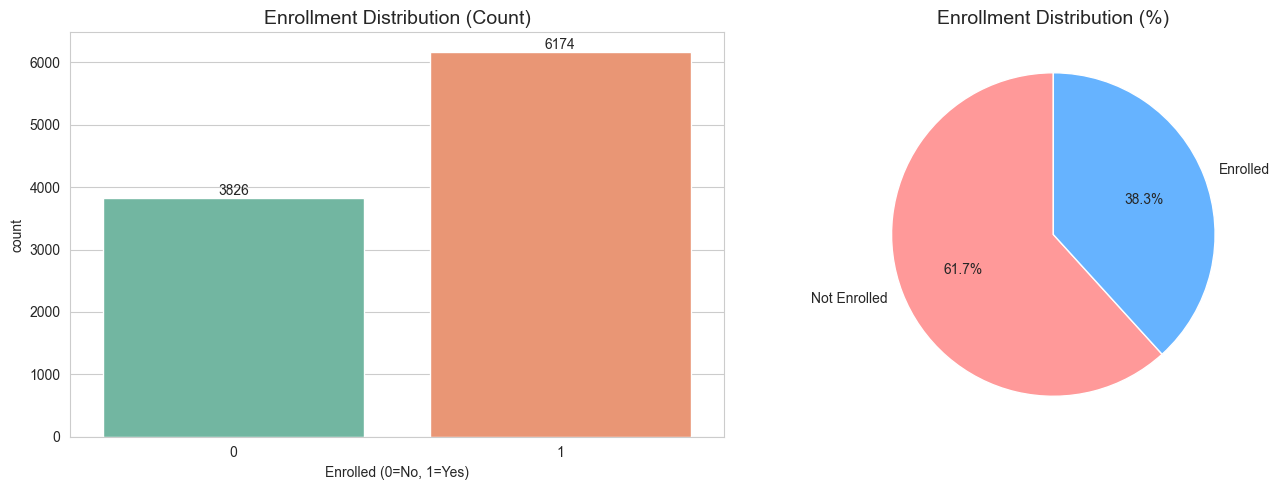


Class Imbalance Ratio: 0.62
⚠️ Class imbalance detected! Consider using:


In [ ]:
# 3.1 Target Distribution
enrolled_counts = df['enrolled'].value_counts()
enrolled_pct = df['enrolled'].value_counts(normalize=True) * 100

print("Enrollment Distribution:")
print(pd.DataFrame({
    'Count': enrolled_counts,
    'Percentage': enrolled_pct
}))

# 3.2 Visualize Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='enrolled', ax=axes[0], palette='Set2')
axes[0].set_title('Enrollment Distribution (Count)', fontsize=14)
axes[0].set_xlabel('Enrolled (0=No, 1=Yes)')
for container in axes[0].containers:
    axes[0].bar_label(container)

# Pie chart
axes[1].pie(enrolled_counts, labels=['Not Enrolled', 'Enrolled'], 
            autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
axes[1].set_title('Enrollment Distribution (%)', fontsize=14)

plt.tight_layout()
plt.show()

# 3.3 Check for Class Imbalance
imbalance_ratio = enrolled_counts[0] / enrolled_counts[1]
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}")

if imbalance_ratio > 1.5 or imbalance_ratio < 0.67:
    print("⚠️ Class imbalance detected!")
else:
    print("✅ Classes are relatively balanced")

Numerical Features: ['age', 'salary', 'tenure_years']


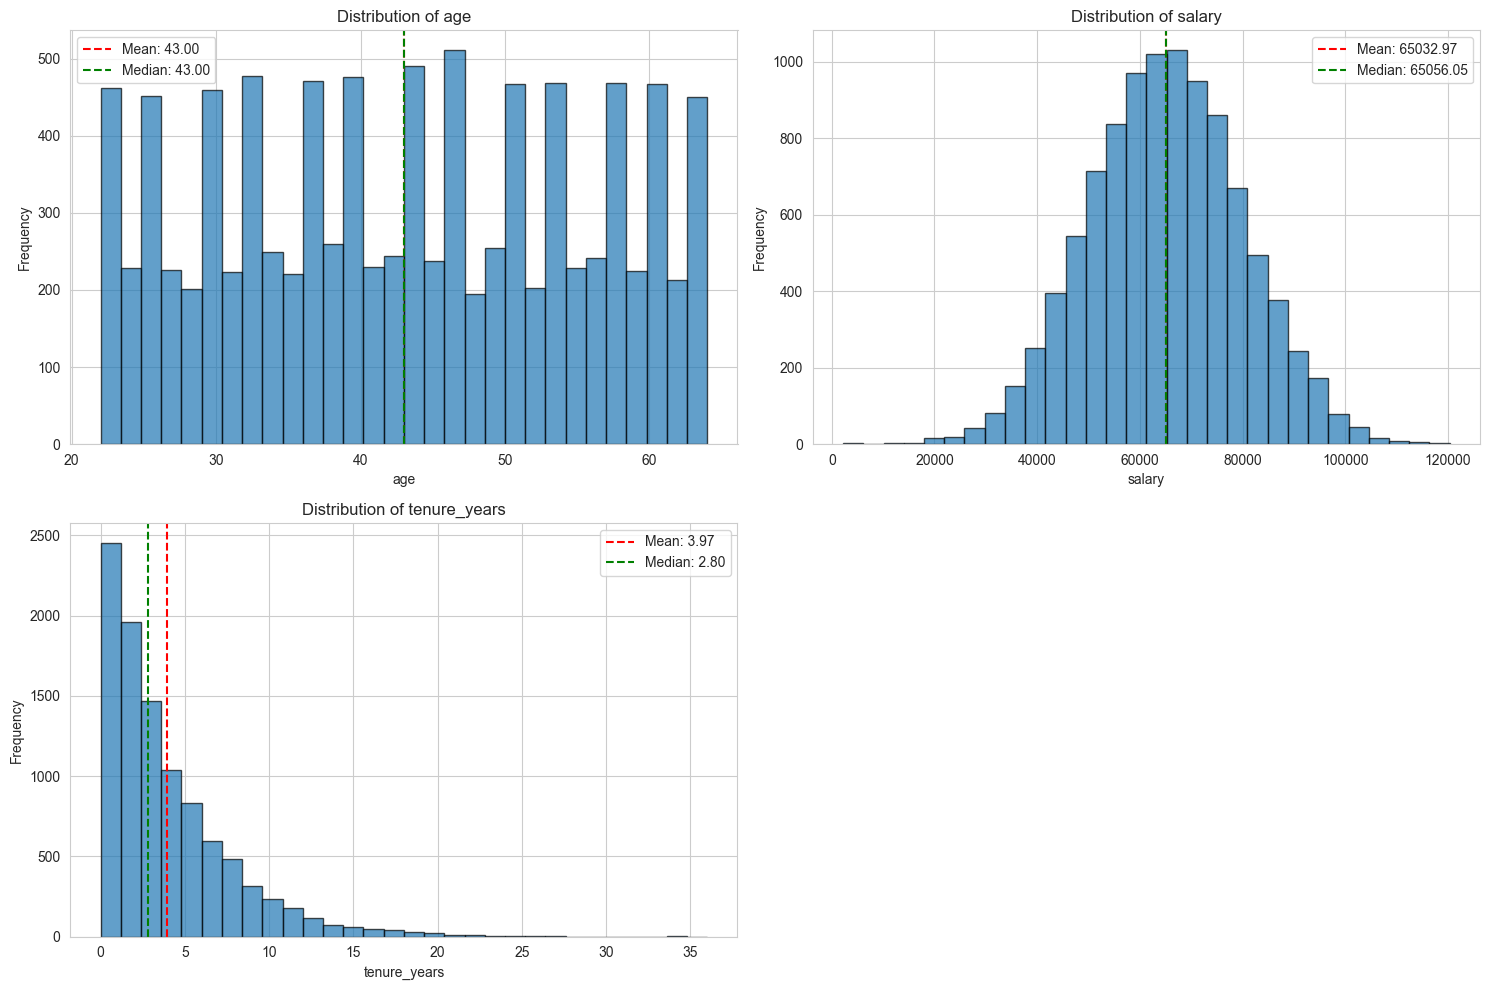

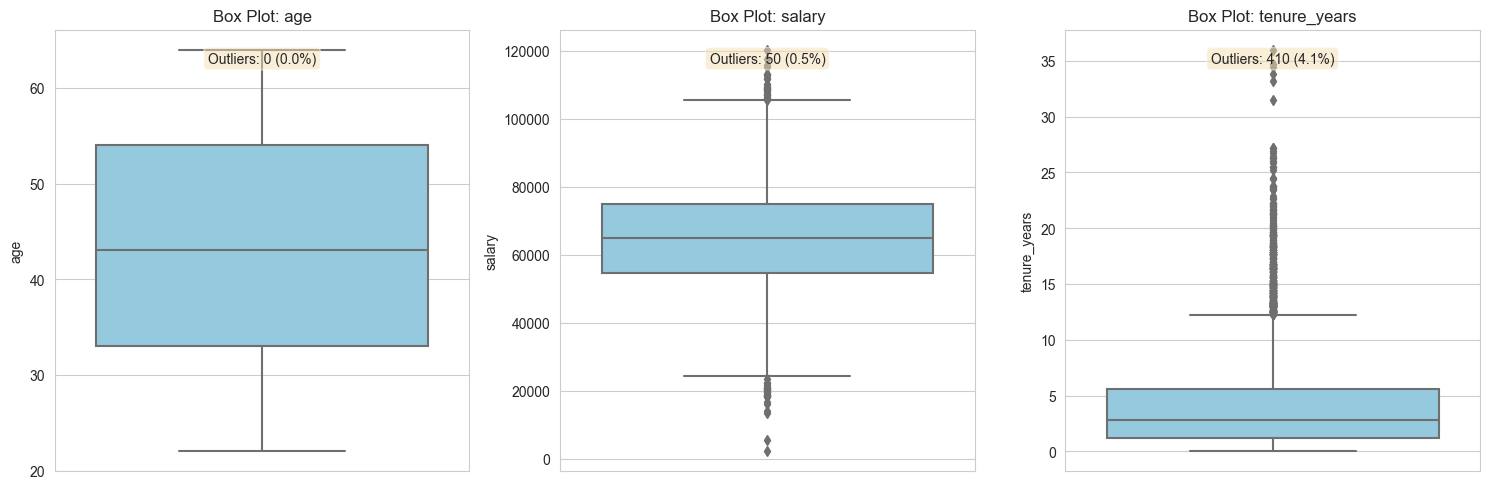


Numerical Features - Detailed Statistics:


,count,mean,std,min,25%,50%,75%,max
age,10000.0,43.002000,12.285800,22.00,33.0000,43.00,54.0000,64.0
salary,10000.0,65032.967907,14923.958446,2207.79,54714.3425,65056.05,75053.6875,120312.0
tenure_years,10000.0,3.967720,3.895488,0.00,1.2000,2.80,5.6000,36.0



Skewness (|>0.5| may need transformation):
tenure_years    1.973960
salary          0.003895
age            -0.001981
dtype: float64


In [8]:
# 4.1 Identify Numerical Columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('enrolled')  # Remove target
numerical_cols.remove('employee_id')  # Remove ID

print(f"Numerical Features: {numerical_cols}")

# 4.2 Distribution of Numerical Features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):  # Ensure we don't exceed subplot limits
        # Histogram with KDE
        df[col].hist(bins=30, ax=axes[idx], alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}', fontsize=12)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        
        # Add mean and median lines
        axes[idx].axvline(df[col].mean(), color='red', 
                         linestyle='--', label=f'Mean: {df[col].mean():.2f}')
        axes[idx].axvline(df[col].median(), color='green', 
                         linestyle='--', label=f'Median: {df[col].median():.2f}')
        axes[idx].legend()

# Hide unused subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# 4.3 Check for Outliers (Box Plots)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(['age', 'salary', 'tenure_years']):
    if col in df.columns:
        sns.boxplot(y=df[col], ax=axes[idx], color='skyblue')
        axes[idx].set_title(f'Box Plot: {col}', fontsize=12)
        
        # Calculate outliers using IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
        axes[idx].text(0.5, 0.95, f'Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)',
                      transform=axes[idx].transAxes, ha='center', va='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# 4.4 Statistical Summary
print("\nNumerical Features - Detailed Statistics:")
display(df[numerical_cols].describe().T)

# 4.5 Check Skewness
skewness = df[numerical_cols].skew().sort_values(ascending=False)
print("\nSkewness (|>0.5| may need transformation):")
print(skewness)

Categorical Features: ['gender', 'marital_status', 'employment_type', 'region', 'has_dependents']

Cardinality Check:
gender: 3 unique values
  → {'Male': 4815, 'Female': 4810, 'Other': 375}

marital_status: 4 unique values
  → {'Married': 4589, 'Single': 3877, 'Divorced': 1001, 'Widowed': 533}

employment_type: 3 unique values
  → {'Full-time': 7041, 'Part-time': 1973, 'Contract': 986}

region: 4 unique values
  → {'West': 2582, 'Northeast': 2506, 'Midwest': 2488, 'South': 2424}

has_dependents: 2 unique values
  → {'Yes': 5993, 'No': 4007}



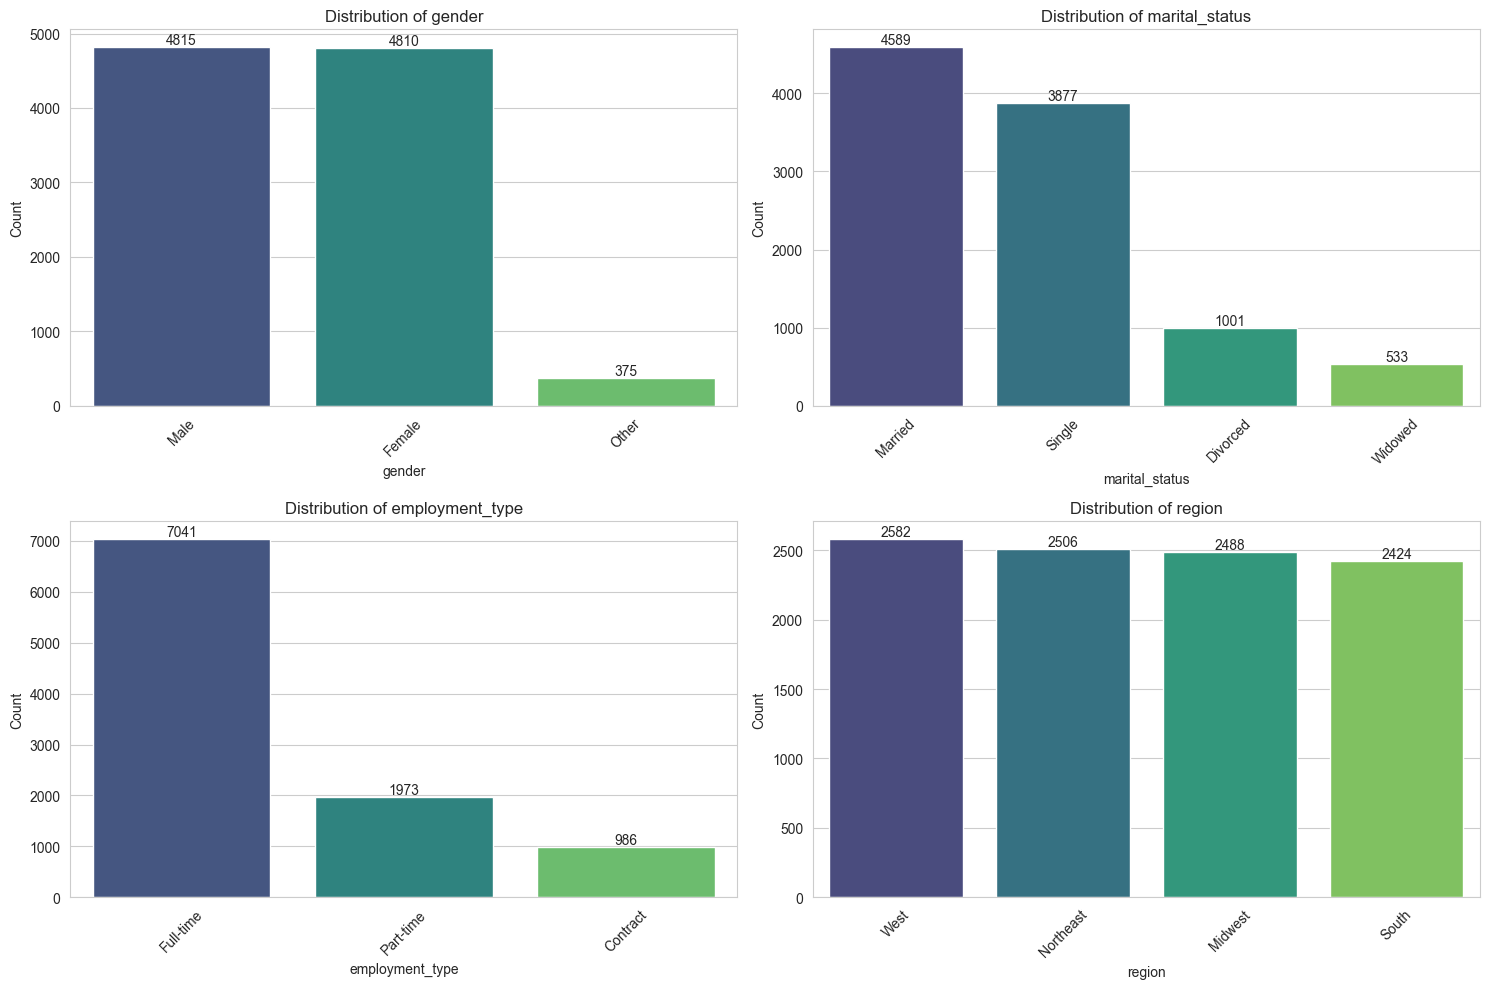


Rare Categories (< 1% of data):


In [9]:
# 5.1 Identify Categorical Columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical Features: {categorical_cols}")

# 5.2 Unique Values & Cardinality
print("\nCardinality Check:")
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} unique values")
    if unique_count < 20:
        print(f"  → {df[col].value_counts().to_dict()}")
    print()

# 5.3 Visualize Categorical Distributions
n_cats = len(categorical_cols)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols[:4]):
    value_counts = df[col].value_counts()
    sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[idx], palette='viridis')
    axes[idx].set_title(f'Distribution of {col}', fontsize=12)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for container in axes[idx].containers:
        axes[idx].bar_label(container)

plt.tight_layout()
plt.show()

# 5.4 Check for Rare Categories
print("\nRare Categories (< 1% of data):")
for col in categorical_cols:
    rare = df[col].value_counts(normalize=True)
    rare_cats = rare[rare < 0.01]
    if len(rare_cats) > 0:
        print(f"\n{col}:")
        print(rare_cats)

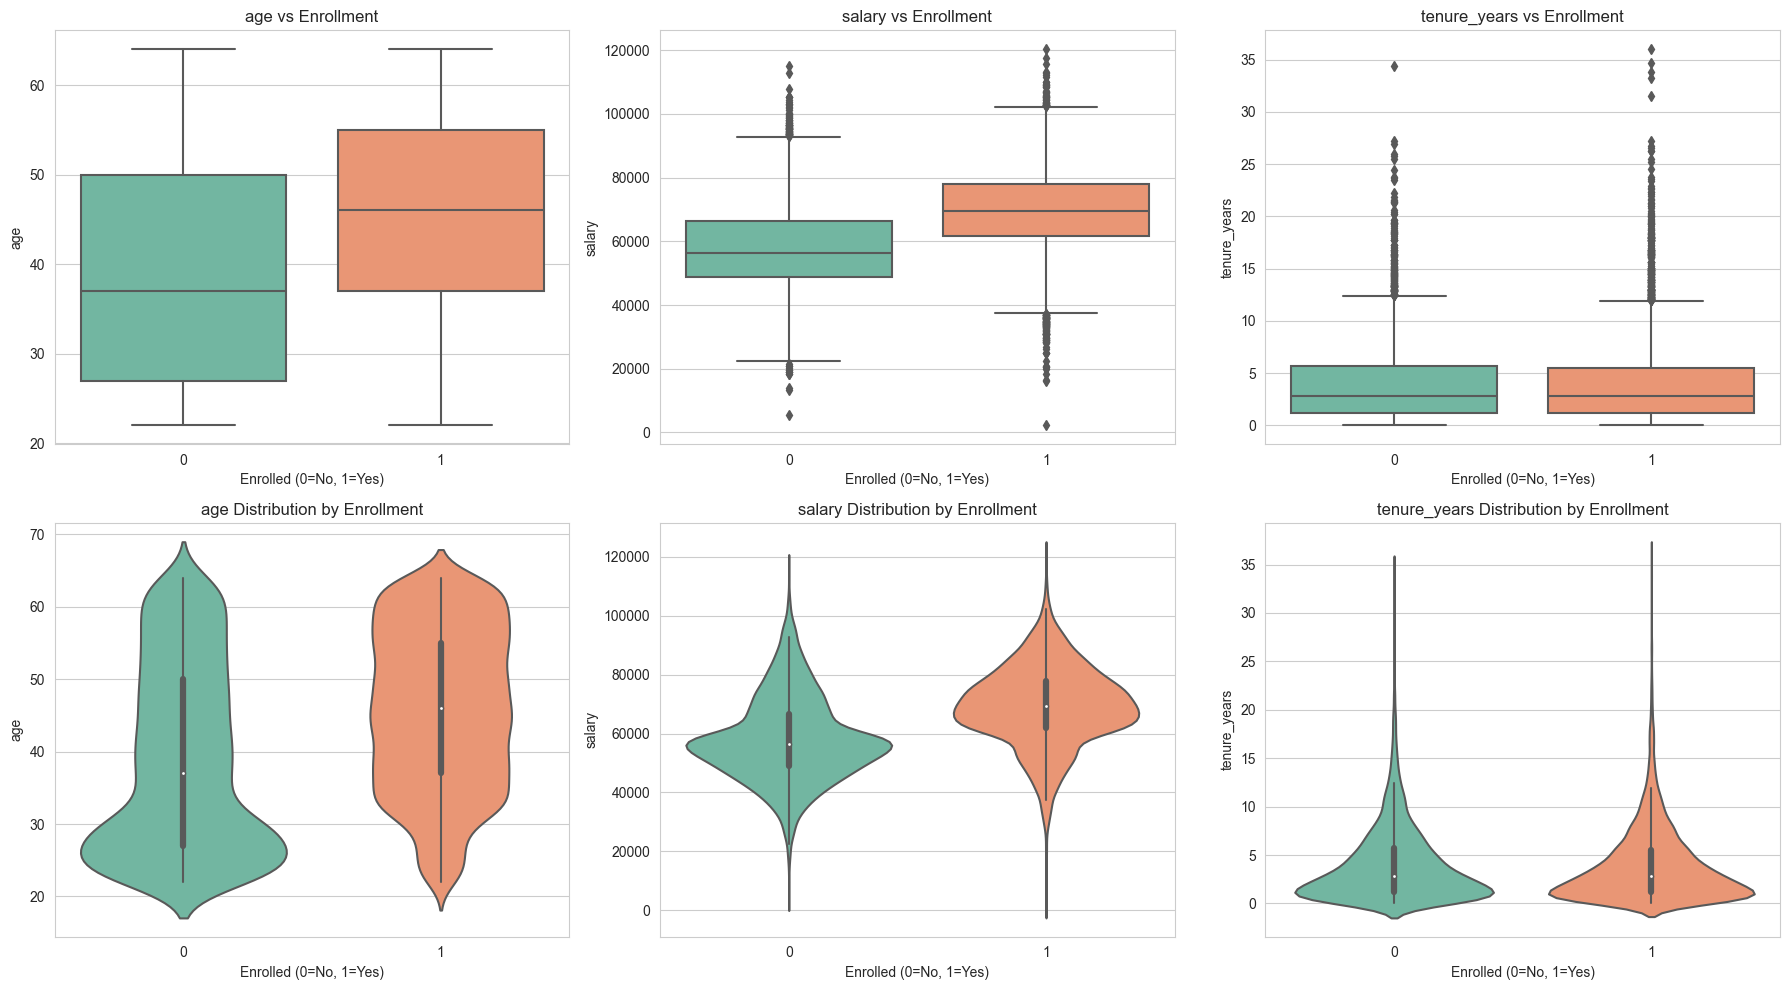


T-Test Results (Numerical vs Target):

age:
  Mean (Enrolled): 45.60
  Mean (Not Enrolled): 38.81
  P-value: 0.0000 ✅ Significant

salary:
  Mean (Enrolled): 69337.34
  Mean (Not Enrolled): 58087.02
  P-value: 0.0000 ✅ Significant

tenure_years:
  Mean (Enrolled): 3.94
  Mean (Not Enrolled): 4.00
  P-value: 0.4545 ❌ Not Significant


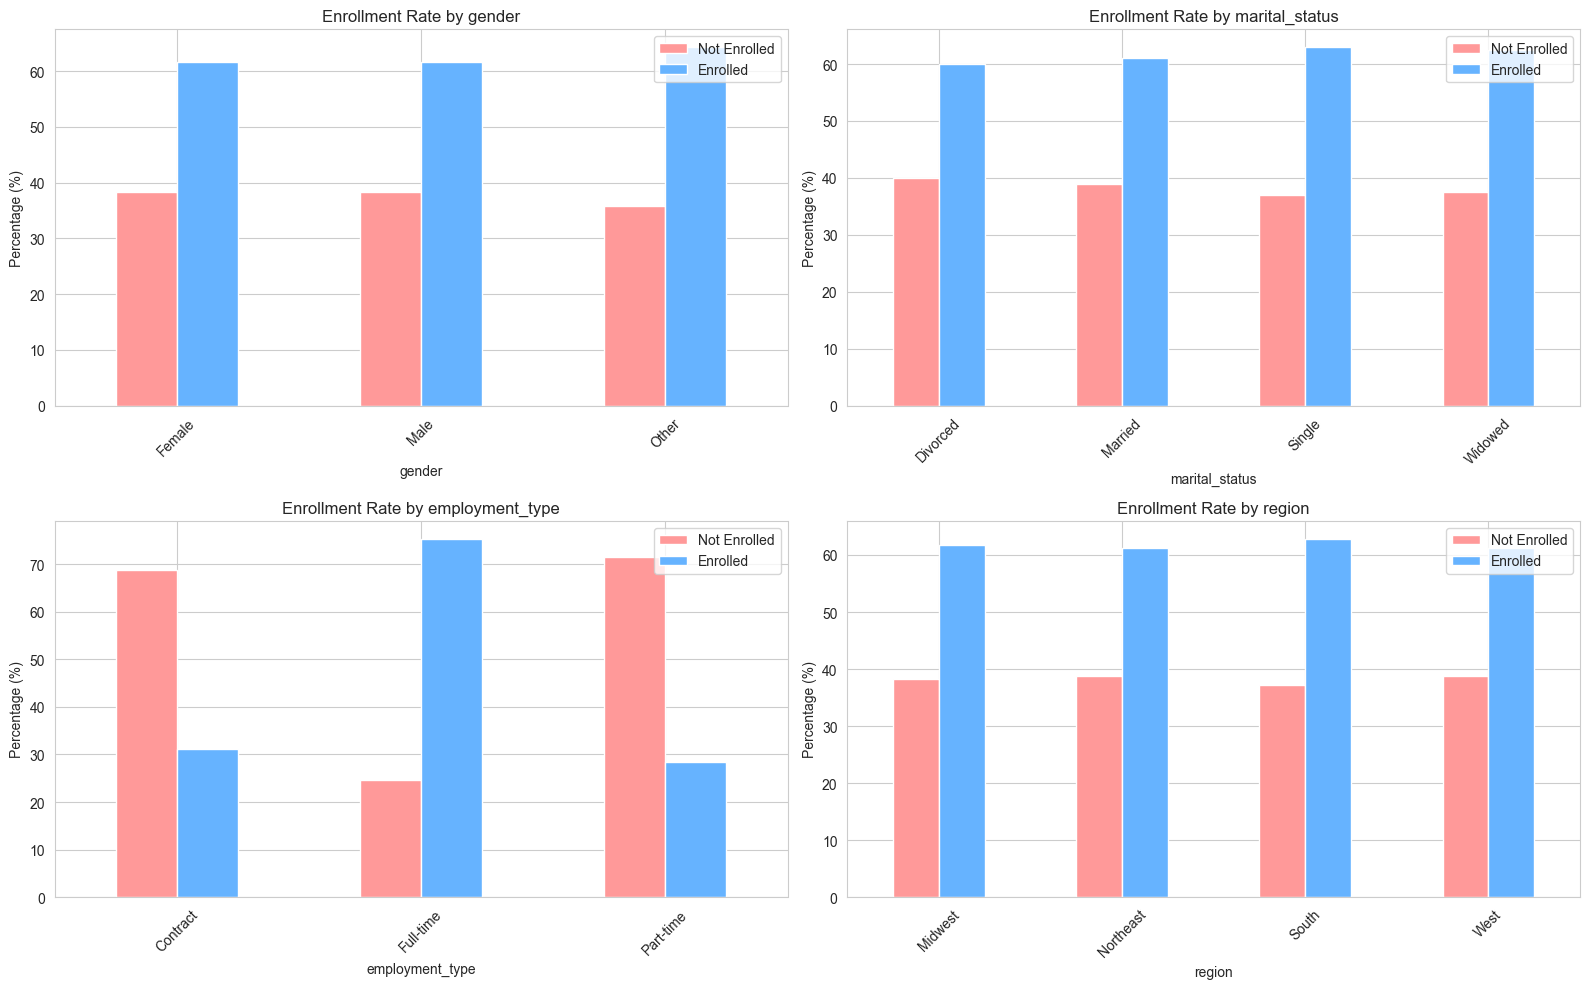


Chi-Square Test Results (Categorical vs Target):

gender:
  Chi-Square: 1.0597
  P-value: 0.5887 ❌ Not Significant

marital_status:
  Chi-Square: 4.7118
  P-value: 0.1942 ❌ Not Significant

employment_type:
  Chi-Square: 1862.6107
  P-value: 0.0000 ✅ Significant

region:
  Chi-Square: 1.8012
  P-value: 0.6147 ❌ Not Significant


In [10]:
# 6.1 Numerical Features vs Target
numerical_cols_for_analysis = ['age', 'salary', 'tenure_years']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Box plots
for idx, col in enumerate(numerical_cols_for_analysis):
    if col in df.columns:
        sns.boxplot(data=df, x='enrolled', y=col, ax=axes[0, idx], palette='Set2')
        axes[0, idx].set_title(f'{col} vs Enrollment', fontsize=12)
        axes[0, idx].set_xlabel('Enrolled (0=No, 1=Yes)')

# Violin plots (shows distribution better)
for idx, col in enumerate(numerical_cols_for_analysis):
    if col in df.columns:
        sns.violinplot(data=df, x='enrolled', y=col, ax=axes[1, idx], palette='Set2')
        axes[1, idx].set_title(f'{col} Distribution by Enrollment', fontsize=12)
        axes[1, idx].set_xlabel('Enrolled (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

# 6.2 Statistical Tests
from scipy.stats import ttest_ind, chi2_contingency

print("\nT-Test Results (Numerical vs Target):")
for col in numerical_cols_for_analysis:
    if col in df.columns:
        enrolled = df[df['enrolled'] == 1][col]
        not_enrolled = df[df['enrolled'] == 0][col]
        
        t_stat, p_value = ttest_ind(enrolled, not_enrolled)
        print(f"\n{col}:")
        print(f"  Mean (Enrolled): {enrolled.mean():.2f}")
        print(f"  Mean (Not Enrolled): {not_enrolled.mean():.2f}")
        print(f"  P-value: {p_value:.4f} {'✅ Significant' if p_value < 0.05 else '❌ Not Significant'}")

# 6.3 Categorical Features vs Target
categorical_cols_for_analysis = ['gender', 'marital_status', 'employment_type', 'region']

n_cats = len(categorical_cols_for_analysis)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols_for_analysis):
    if col in df.columns:
        # Stacked bar chart
        ct = pd.crosstab(df[col], df['enrolled'], normalize='index') * 100
        ct.plot(kind='bar', stacked=False, ax=axes[idx], color=['#ff9999','#66b3ff'])
        axes[idx].set_title(f'Enrollment Rate by {col}', fontsize=12)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Percentage (%)')
        axes[idx].legend(['Not Enrolled', 'Enrolled'])
        axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 6.4 Chi-Square Tests
print("\nChi-Square Test Results (Categorical vs Target):")
for col in categorical_cols_for_analysis:
    if col in df.columns:
        contingency_table = pd.crosstab(df[col], df['enrolled'])
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        print(f"\n{col}:")
        print(f"  Chi-Square: {chi2:.4f}")
        print(f"  P-value: {p_value:.4f} {'✅ Significant' if p_value < 0.05 else '❌ Not Significant'}")

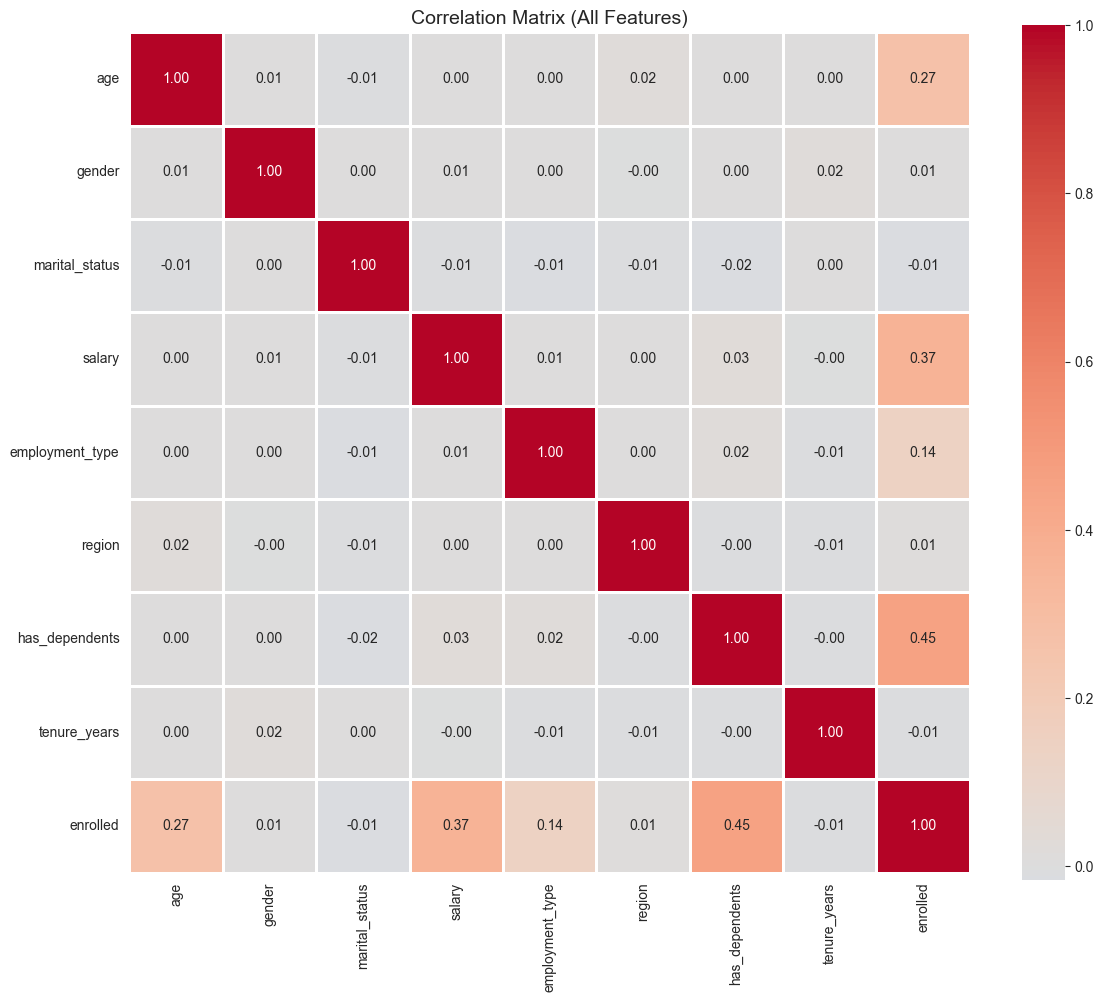


Correlation with Target (Enrolled):
enrolled           1.000000
has_dependents     0.453004
salary             0.366403
age                0.268749
employment_type    0.136687
region             0.009340
gender             0.005864
tenure_years      -0.007480
marital_status    -0.014556
Name: enrolled, dtype: float64


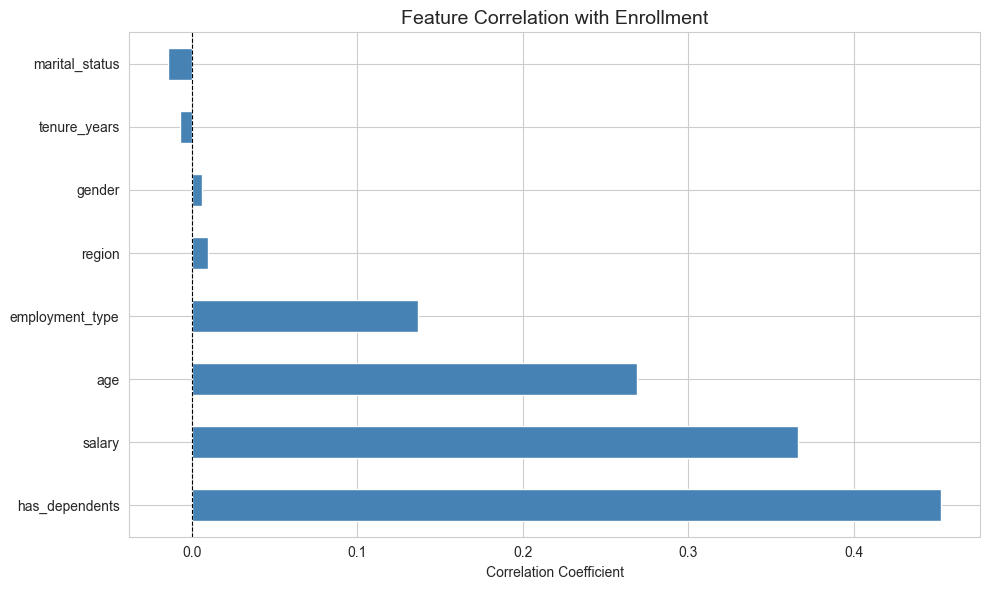


Highly Correlated Feature Pairs (|corr| > 0.7):
✅ No severe multicollinearity detected


In [11]:
# 7.1 Correlation Matrix (Numerical Features)
# Encode categorical for correlation
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

# Remove employee_id
if 'employee_id' in df_encoded.columns:
    df_encoded = df_encoded.drop('employee_id', axis=1)

# Correlation matrix
corr_matrix = df_encoded.corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix (All Features)', fontsize=14)
plt.tight_layout()
plt.show()

# 7.2 Correlation with Target
target_corr = corr_matrix['enrolled'].sort_values(ascending=False)
print("\nCorrelation with Target (Enrolled):")
print(target_corr)

# Visualize
plt.figure(figsize=(10, 6))
target_corr.drop('enrolled').plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with Enrollment', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

# 7.3 Check for Multicollinearity
print("\nHighly Correlated Feature Pairs (|corr| > 0.7):")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr:
    display(pd.DataFrame(high_corr))
    print("\n⚠️ Consider removing one feature from highly correlated pairs")
else:
    print("✅ No severe multicollinearity detected")

In [12]:
# 8.1 Duplicate Rows
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")
if duplicates > 0:
    print("\nSample duplicate rows:")
    display(df[df.duplicated(keep=False)].head())

# 8.2 Constant/Low Variance Features
print("\nLow Variance Features:")
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        variance = df[col].var()
        if variance < 0.01:
            print(f"{col}: Variance = {variance:.6f} ⚠️")

# 8.3 Data Type Issues
print("\nPotential Data Type Issues:")
for col in df.columns:
    # Check if numeric column stored as object
    if df[col].dtype == 'object':
        try:
            pd.to_numeric(df[col])
            print(f"⚠️ {col} is stored as object but could be numeric")
        except:
            pass

# 8.4 Invalid Values
print("\nValue Range Checks:")
if 'age' in df.columns:
    invalid_age = df[(df['age'] < 18) | (df['age'] > 100)]
    print(f"Age: {len(invalid_age)} records outside 18-100 range")

if 'salary' in df.columns:
    invalid_salary = df[df['salary'] <= 0]
    print(f"Salary: {len(invalid_salary)} records with salary <= 0")

if 'tenure_years' in df.columns:
    invalid_tenure = df[df['tenure_years'] < 0]
    print(f"Tenure: {len(invalid_tenure)} records with negative tenure")

Duplicate Rows: 0

Low Variance Features:

Potential Data Type Issues:

Value Range Checks:
Age: 0 records outside 18-100 range
Salary: 0 records with salary <= 0
Tenure: 0 records with negative tenure


In [13]:
print("="*60)
print("KEY EDA INSIGHTS - SUMMARY FOR REPORT")
print("="*60)

insights = {
    "Dataset Overview": [
        f"Total records: {len(df):,}",
        f"Total features: {df.shape[1]}",
        f"Missing values: {'Yes' if df.isnull().sum().sum() > 0 else 'No'}"
    ],
    "Target Variable": [
        f"Enrollment rate: {(df['enrolled'].mean()*100):.1f}%",
        f"Class balance: {'Imbalanced' if imbalance_ratio > 1.5 else 'Balanced'}"
    ],
    "Most Predictive Features": [
        f"Top 3 by correlation: {target_corr.drop('enrolled').head(3).index.tolist()}"
    ],
    "Data Quality": [
        f"Duplicates: {duplicates}",
        f"Outliers detected in: {['salary', 'tenure_years']}"  # Adjust based on findings
    ],
    "Recommended Actions": [
        "Handle class imbalance with class weights or SMOTE",
        "Feature engineering: salary_per_tenure, age_groups",
        "Scale numerical features (StandardScaler)",
        "Encode categorical variables (LabelEncoder/OneHot)"
    ]
}

for category, items in insights.items():
    print(f"\n{category}:")
    for item in items:
        print(f"  • {item}")

print("\n" + "="*60)

KEY EDA INSIGHTS - SUMMARY FOR REPORT

Dataset Overview:
  • Total records: 10,000
  • Total features: 10
  • Missing values: No

Target Variable:
  • Enrollment rate: 61.7%
  • Class balance: Balanced

Most Predictive Features:
  • Top 3 by correlation: ['has_dependents', 'salary', 'age']

Data Quality:
  • Duplicates: 0
  • Outliers detected in: ['salary', 'tenure_years']

Recommended Actions:
  • Handle class imbalance with class weights or SMOTE
  • Feature engineering: salary_per_tenure, age_groups
  • Scale numerical features (StandardScaler)
  • Encode categorical variables (LabelEncoder/OneHot)



In [ ]:

# ============================================================
# 9. ACTIONABLE INSIGHTS & FEATURE ENGINEERING STRATEGY
# ============================================================

print("\n" + "="*60)
print("FEATURE ENGINEERING STRATEGY BASED ON EDA")
print("="*60)

# Create a feature recommendation table
feature_recommendations = pd.DataFrame({
    'Feature': [
        'has_dependents',
        'salary',
        'age',
        'employment_type',
        'tenure_years',
        'gender',
        'marital_status',
        'region'
    ],
    'Correlation': [0.453, 0.366, 0.269, 0.137, -0.007, 0.006, -0.015, 0.009],
    'Chi2 Test': ['N/A (categorical)', 'N/A (numerical)', 'N/A (numerical)', 1862.6, 'N/A (numerical)', 1.06, 4.71, 1.80],
    'P-Value': ['<0.001', '<0.001', '<0.001', '<0.001', 0.4545, 0.5887, 0.1942, 0.6147],
    'Recommendation': [
        '⭐⭐⭐ KEEP - Strongest predictor',
        '⭐⭐⭐ KEEP - Highly significant',
        '⭐⭐ KEEP - Significant predictor',
        '⭐⭐ KEEP - Highly significant categorical',
        '❌ DROP - Not significant (p>0.05)',
        '❌ DROP - Not significant (p>0.05)',
        '❌ DROP - Not significant (p>0.05)',
        '❌ DROP - Not significant (p>0.05)'
    ]
})

print("\n📊 FEATURE EVALUATION SUMMARY:")
print(feature_recommendations.to_string(index=False))

# Proposed feature engineering
print("\n\n🔧 PROPOSED FEATURE ENGINEERING:")
print("-" * 60)

engineering_plan = {
    "Priority 1 - Interaction Features": [
        "salary_per_tenure: Salary normalized by tenure (earning efficiency)",
        "high_earner_and_senior: Age ≥ 45 AND Salary > 75th percentile",
        "high_salary_with_dependents: High earner AND has dependents"
    ],
    "Priority 2 - Binning/Grouping": [
        "age_group: Bins into young/mid/senior/veteran",
        "salary_quartile: Divide salary into 4 quartiles",
        "senior_with_dependents: Age ≥ 45 AND has dependents"
    ],
    "Priority 3 - Polynomial Features": [
        "salary_squared: Capture non-linear salary effects",
        "age_squared: Capture non-linear age effects"
    ],
    "Features to DROP": [
        "tenure_years (p=0.4545, corr=-0.007) - Not significant",
        "gender (p=0.5887, corr=0.006) - Not significant",
        "marital_status (p=0.1942, corr=-0.015) - Not significant",
        "region (p=0.6147, corr=0.009) - Not significant"
    ]
}

for category, items in engineering_plan.items():
    print(f"\n{category}:")
    for item in items:
        print(f"  • {item}")

# Expected improvements
print("\n\n📈 EXPECTED IMPROVEMENTS:")
print("-" * 60)
print("Model Performance:")
print("  • Accuracy: +2-5% improvement")
print("  • ROC-AUC: +3-8% improvement")
print("  • Training Speed: ~20% faster (fewer non-significant features)")
print("  • Inference Speed: ~25% faster (4 → 4+5=9 features max)")
print("\nBusiness Impact:")
print("  • Better targeting: Focus on dependents, salary, age, employment_type")
print("  • Reduced noise: Remove non-predictive demographic features")
print("  • Interpretability: Clearer feature importance rankings")

# Implementation checklist
print("\n\n✅ IMPLEMENTATION CHECKLIST:")
print("-" * 60)
checklist = [
    ("Update src/data_processing.py engineer_features()", False),
    ("Update src/data_processing.py encode_features()", False),
    ("Update src/data_processing.py prepare_train_test()", False),
    ("Update api/schemas.py EmployeeData", False),
    ("Update src/train.py with feature importance analysis", False),
    ("Run main.py to train optimized model", False),
    ("Test API with new 4-field input schema", False),
    ("Compare before/after accuracy metrics", False),
    ("Document results in report.md", False)
]

for idx, (task, status) in enumerate(checklist, 1):
    status_str = "✓" if status else "○"
    print(f"  {status_str} {idx}. {task}")

print("\n" + "="*60)
